# Stripe-Gain pipeline — Cell-1: Imports, paths, helpers

**What this cell does**
- Sets input/output paths.
- Provides I/O helpers with safe integer↔float round-trip.
- Implements:
  - `robust_profile(img, axis, method, trim)` → 1D profile (median or trimmed-mean).
  - `smooth_profile(prof, filter, win, polyorder)` → 1D baseline (median / gaussian / mean / Savitzky-Golay).
  - `compute_gain(prof, baseline, normalize)` → 1D gain, optionally normalized to median=1.
  - `apply_gain(img, gain, axis)` → broadcast gain → corrected image.
- Optional CuPy: profile median computed on GPU if available (baseline smoothing stays CPU — it's 1D and tiny).

**Key parameters**
- `axis_profile`: `0` for **vertical stripes** (gain per column), `1` for **horizontal stripes** (gain per row).
- `method`: `"median"` or `"trimmed_mean"` (robustness to features).
- `filter`: `"gaussian"`, `"median"`, `"mean"`, `"savgol"`.
- `win` (odd): smoothing window along the profile; start with 9–31.
- `polyorder` (Savitzky–Golay): typically 2–3 and `< win`.

**Notes**
- Handles **8-bit / 16-bit / 32-bit** identically: we process in float32, then round-trip to the original dtype on save.
- If your specimen occupies a very large fraction of some lines, prefer `method="median"` or increase trimming.


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, Tuple
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.signal import savgol_filter

# Optional GPU for the 1D profile
try:
    import cupy as cp
    CUPY_OK = True
except Exception:
    CUPY_OK = False
    cp = None

# ---------------- Paths ----------------
DATA_DIR = Path("/home/askiran/data/Normalized_log/114")  # adjust as needed
OUT_DIR  = DATA_DIR / "stripefix_out_gain"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# State specific to Stripe-Gain
STATE_SG: Dict[str, Any] = dict(
    last_path=None, last_img=None,
    last_profile=None, last_baseline=None, last_gain=None,
    last_axis_profile=0, last_corrected=None, last_meta=None
)

# ---------------- I/O helpers ----------------
def to_float32(img: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    meta = {"dtype": img.dtype}
    if np.issubdtype(img.dtype, np.integer):
        info = np.iinfo(img.dtype)
        meta.update({"imin": info.min, "imax": info.max})
        x = (img.astype(np.float32) - info.min) / max(1.0, (info.max - info.min))
    elif np.issubdtype(img.dtype, np.floating):
        x = img.astype(np.float32, copy=False)
        meta.update({"imin": None, "imax": None})
    else:
        raise TypeError(f"Unsupported dtype: {img.dtype}")
    return x, meta

def from_float32(x: np.ndarray, meta: Dict[str, Any]) -> np.ndarray:
    dtype = meta["dtype"]
    if np.issubdtype(dtype, np.integer):
        imin, imax = meta["imin"], meta["imax"]
        y = np.clip(x, 0.0, 1.0) * (imax - imin) + imin
        return np.rint(y).astype(dtype)
    elif np.issubdtype(dtype, np.floating):
        return x.astype(dtype, copy=False)
    else:
        raise TypeError(f"Unsupported dtype: {dtype}")

def imread_gray(path: Path) -> Tuple[np.ndarray, Dict[str, Any]]:
    arr = iio.imread(path)
    if arr.ndim == 3:  # RGB/RGBA → gray (luma)
        if arr.shape[-1] in (3,4):
            arr = (0.2126*arr[...,0] + 0.7152*arr[...,1] + 0.0722*arr[...,2]).astype(arr.dtype)
        else:
            arr = arr[...,0]
    x, meta = to_float32(arr)
    return x, meta

def imsave_roundtrip(path: Path, x_float: np.ndarray, meta: Dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(path, from_float32(x_float, meta))

def list_images(folder: Path):
    exts = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def safe_divide(a: np.ndarray, b: np.ndarray, eps: float=1e-6) -> np.ndarray:
    return a / (b + eps)

# ---------------- Core: robust profile, smoothing, gain, apply ----------------
def robust_profile(img: np.ndarray, axis: int=0, method: str="median", trim: float=10.0) -> np.ndarray:
    """
    Compute 1D profile along `axis`:
      axis=0 → collapse rows → length = width (gain per column, vertical stripes)
      axis=1 → collapse cols → length = height (gain per row, horizontal stripes)
    method: "median" or "trimmed_mean"; trim is % discarded on *each* side for trimmed mean.
    """
    if method == "median":
        if CUPY_OK:
            prof = cp.asnumpy(cp.median(cp.asarray(img), axis=axis))
        else:
            prof = np.median(img, axis=axis)
        return prof.astype(np.float32, copy=False)

    elif method == "trimmed_mean":
        trim = float(np.clip(trim, 0.0, 49.0))
        lo, hi = np.percentile(img, [trim, 100.0 - trim], axis=axis, keepdims=True)
        mask = (img >= lo) & (img <= hi)
        # avoid division by count=0
        count = np.maximum(mask.sum(axis=axis), 1)
        prof = (img * mask).sum(axis=axis) / count
        return prof.astype(np.float32, copy=False)

    else:
        raise ValueError("method must be 'median' or 'trimmed_mean'")

def smooth_profile(prof: np.ndarray, filter: str="gaussian", win: int=21, polyorder: int=3) -> np.ndarray:
    """
    Smooth a 1D profile to get the 'no-stripe' baseline.
    filter: 'gaussian' | 'median' | 'mean' | 'savgol'
      - gaussian: sigma ~ win/3
      - median: window size = win (odd)
      - mean: moving average (uniform) with window = win
      - savgol: Savitzky–Golay (odd win, polyorder<win)
    """
    win = int(max(3, win))
    if win % 2 == 0: win += 1
    f = filter.lower()

    if f == "gaussian":
        sigma = max(win/3.0, 1.0)
        base = ndi.gaussian_filter1d(prof, sigma=sigma, mode="nearest")
    elif f == "median":
        base = ndi.median_filter(prof, size=win, mode="nearest")
    elif f == "mean":
        base = ndi.uniform_filter1d(prof, size=win, mode="nearest")
    elif f == "savgol":
        polyorder = int(np.clip(polyorder, 1, win-2))
        base = savgol_filter(prof, window_length=win, polyorder=polyorder, mode="interp")
    else:
        raise ValueError("Unknown filter type")
    return base.astype(np.float32, copy=False)

def compute_gain(prof: np.ndarray, baseline: np.ndarray, normalize: bool=True, eps: float=1e-6) -> np.ndarray:
    gain = safe_divide(prof.astype(np.float32, copy=False), baseline.astype(np.float32, copy=False), eps=eps)
    if normalize:
        med = float(np.median(gain))
        if med > 0: gain = gain / med
    return gain.astype(np.float32, copy=False)

def apply_gain(img: np.ndarray, gain: np.ndarray, axis: int=0, clip_percentiles=(0.1, 99.9)) -> np.ndarray:
    """
    Broadcast 1D gain to 2D and divide.
    axis: 0→gain per column, axis=1→gain per row
    Optional percentile-clipping of corrected image for safety (disabled if None).
    """
    if axis == 0:
        gain_2d = np.broadcast_to(gain[None, :], img.shape)
    else:
        gain_2d = np.broadcast_to(gain[:, None], img.shape)

    corrected = safe_divide(img, gain_2d)
    if clip_percentiles:
        lo, hi = np.percentile(corrected, clip_percentiles)
        corrected = np.clip(corrected, lo, hi)
        # re-normalize to [0,1] to preserve original global intensity span
        corrected = (corrected - lo) / max(hi - lo, 1e-6)
    return corrected.astype(np.float32, copy=False)

print("Stripe-Gain helpers ready. CUPY_OK =", CUPY_OK)


Stripe-Gain helpers ready. CUPY_OK = True


# Stripe-Gain pipeline — Cell-2: Single-image profile & baseline (UI)

**What this cell does**
- Choose one image from `DATA_DIR`.
- Choose stripe orientation → sets **profile axis**:
  - Vertical stripes → `axis_profile=0` (median over rows → profile length = width).
  - Horizontal stripes → `axis_profile=1` (median over cols → profile length = height).
- Build **robust profile** and its **smoothed baseline**; preview both.

**Parameters**
- `method`: `"median"` (default; robust) or `"trimmed_mean"`.
- `trim %` (for trimmed mean): discard % from each tail (5–20% typical).
- `filter`: `"gaussian" | "median" | "mean" | "savgol"`.
- `win`: odd window (start 21).
- `polyorder` (Savgol only): 2–3 typical (must be `< win`).

**Tuning**
- If profile is jagged → increase `win` or use `median`.
- If you want very smooth baseline → `gaussian` with larger `win`, or `savgol` with modest `polyorder`.


In [2]:
from ipywidgets import Dropdown, RadioButtons, IntSlider, FloatSlider, Button, VBox, HBox, Output, HTML

paths = list_images(DATA_DIR)
assert paths, f"No images found in {DATA_DIR}"

img_dd = Dropdown(options=[(p.name, p) for p in paths], description="Image:", layout={"width":"400px"})
orient_rb = RadioButtons(options=[("Vertical stripes (gain per column)",0),
                                  ("Horizontal stripes (gain per row)",1)],
                         value=0, description="Orientation:")
method_rb = RadioButtons(options=["median","trimmed_mean"], value="median", description="Profile:")
trim_sl   = FloatSlider(value=10.0, min=0.0, max=49.0, step=1.0, description="Trim %")
filt_dd   = Dropdown(options=["gaussian","median","mean","savgol"], value="gaussian", description="Filter:")
win_sl    = IntSlider(value=21, min=3, max=199, step=2, description="Win")
poly_sl   = IntSlider(value=3, min=2, max=15, step=1, description="Poly (Savgol)")

run_btn = Button(description="Build profile+baseline", button_style="primary")
out2 = Output()

def _build_profile(_=None):
    with out2:
        out2.clear_output()
        img_path = img_dd.value
        img, meta = imread_gray(img_path)
        axis_profile = int(orient_rb.value)
        prof = robust_profile(img, axis=axis_profile, method=method_rb.value, trim=trim_sl.value)
        base = smooth_profile(prof, filter=filt_dd.value, win=win_sl.value, polyorder=poly_sl.value)

        STATE_SG.update(last_path=img_path, last_img=img, last_profile=prof, last_baseline=base,
                        last_axis_profile=axis_profile, last_meta=meta)

        xs = np.arange(len(prof))
        fig, axs = plt.subplots(2, 1, figsize=(10, 6))
        axs[0].plot(xs, prof, label="profile")
        axs[0].plot(xs, base, label="baseline", linewidth=2)
        axs[0].set_title(f"Profile vs Baseline  (axis={axis_profile})")
        axs[0].legend()

        axs[1].plot(xs, prof - base)
        axs[1].set_title("Residual (profile - baseline)")
        plt.tight_layout()
        plt.show()

run_btn.on_click(_build_profile)
display(VBox([HBox([img_dd]), HBox([orient_rb]), HBox([method_rb, trim_sl]),
              HBox([filt_dd, win_sl, poly_sl]), run_btn, out2]))

_build_profile()


%%markdown
# Stripe-Gain pipeline — Cell-3: Gain, correction, and visualization

**What this cell does**
- Computes `gain = profile / baseline` (median-normalized to ~1.0).
- Broadcasts to 2-D and divides image by the gain.
- Visualizes **Original vs Corrected**, and shows the **gain curve**.

**Parameters**
- `normalize_gain`: force median(gain)=1 to avoid global intensity drift (recommended).
- `clip_percentiles`: clamps corrected image to avoid extreme outliers (set `None` to disable; default (0.1,99.9)).

**Tips**
- If corrected image looks too flat → reduce `win` or switch filter from `median`→`gaussian`.
- If residual stripes persist → increase `win` a bit, or use `median` filter for a stronger equalizer.


In [8]:
from ipywidgets import Checkbox, FloatRangeSlider

assert STATE_SG.get("last_profile") is not None, "Run Cell-2 first."

norm_cb = Checkbox(value=True, description="Normalize gain to median=1")
clip_rng = FloatRangeSlider(value=(0.1, 99.9), min=0.0, max=100.0, step=0.1, description="Clip %", layout={"width":"400px"})
apply_btn = Button(description="Compute correction", button_style="primary")
out3 = Output()

def _apply_gain(_=None):
    with out3:
        out3.clear_output()
        img = STATE_SG["last_img"]
        prof, base = STATE_SG["last_profile"], STATE_SG["last_baseline"]
        axis_profile = STATE_SG["last_axis_profile"]

        gain = compute_gain(prof, base, normalize=norm_cb.value)
        STATE_SG["last_gain"] = gain

        perc = tuple(clip_rng.value)
        corrected = apply_gain(img, gain, axis=axis_profile, clip_percentiles=perc)
        STATE_SG["last_corrected"] = corrected

        # shared display range
        both = np.concatenate([img.ravel(), corrected.ravel()])
        vmin, vmax = np.percentile(both, [1, 99]).astype(float)

        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow(img, cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original");  axs[0].axis("off")
        axs[1].imshow(corrected, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Corrected"); axs[1].axis("off")
        axs[2].plot(gain); axs[2].set_title("Gain (1D)"); axs[2].grid(True)
        plt.tight_layout(); plt.show()

apply_btn.on_click(_apply_gain)
display(VBox([HBox([norm_cb, clip_rng, apply_btn]), out3]))

_apply_gain()


%%markdown
# Stripe-Gain pipeline — Cell-4: Quality metrics (SSIM / PSNR / MSE) + optional stripe mask

**What this cell does**
- Reports **SSIM**, **PSNR**, **MSE** between *Original* and *Corrected* (for sanity — higher SSIM/PSNR is typical).
- Optional **1-D stripe mask** (diagnostic): runs a simple outlier detector on the **gain** curve to highlight suspect lines.

**Parameters**
- `snr_mask` (diagnostic): higher = stricter; start at 3.0–5.0.

**Failure points (with confidence)**
- Skimage missing → install `scikit-image` (90%).  
- Extremely flat images → detector may flag nothing or everything (60%).


SSIM: 0.728729   PSNR: 18.836 dB   MSE: 1.307519e-02


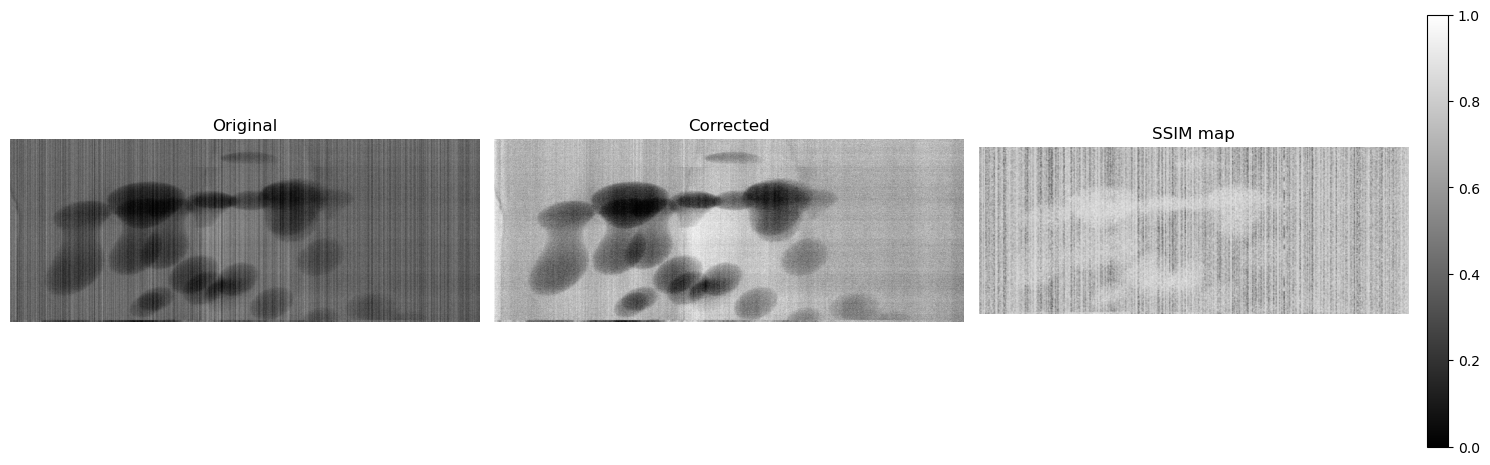

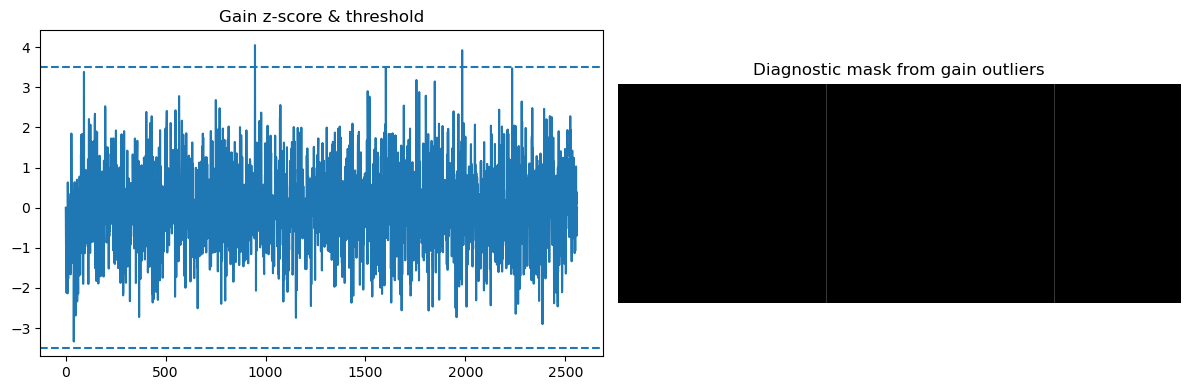

In [9]:
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr, mean_squared_error as mse

assert STATE_SG.get("last_corrected") is not None, "Run Cell-3 to compute correction."

original  = STATE_SG["last_img"].astype(np.float32, copy=False)
corrected = STATE_SG["last_corrected"].astype(np.float32, copy=False)

data_min = float(min(original.min(), corrected.min()))
data_max = float(max(original.max(), corrected.max()))
data_range = max(data_max - data_min, 1e-6)

ssim_val, ssim_map = ssim(original, corrected, data_range=data_range, full=True)
psnr_val = psnr(original, corrected, data_range=data_range)
mse_val  = mse(original, corrected)

print(f"SSIM: {ssim_val:.6f}   PSNR: {psnr_val:.3f} dB   MSE: {mse_val:.6e}")

fig, axs = plt.subplots(1,3,figsize=(15,5))
both = np.concatenate([original.ravel(), corrected.ravel()])
vmin, vmax = np.percentile(both, [1,99]).astype(float)
axs[0].imshow(original,  cmap="gray", vmin=vmin, vmax=vmax); axs[0].set_title("Original");  axs[0].axis("off")
axs[1].imshow(corrected, cmap="gray", vmin=vmin, vmax=vmax); axs[1].set_title("Corrected"); axs[1].axis("off")
im = axs[2].imshow(ssim_map, cmap="gray", vmin=0.0, vmax=1.0); axs[2].set_title("SSIM map"); axs[2].axis("off")
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# --- optional: quick mask by gain outliers (diagnostic) ---
snr_mask = 3.5
g = STATE_SG["last_gain"].astype(np.float32, copy=False)
g_norm = (g - np.median(g)) / (np.std(g) + 1e-6)

# simple robust z-score thresholding as a stand-in for a more formal detector
thr = snr_mask
mask_1d = (np.abs(g_norm) > thr).astype(np.float32)
axis_used = STATE_SG["last_axis_profile"]
mask_img = np.repeat(mask_1d[None,:], original.shape[0], axis=0) if axis_used==0 else \
           np.repeat(mask_1d[:,None], original.shape[1], axis=1)

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(g_norm); ax[0].axhline(+thr, ls="--"); ax[0].axhline(-thr, ls="--"); ax[0].set_title("Gain z-score & threshold")
ax[1].imshow(mask_img, cmap="gray"); ax[1].set_title("Diagnostic mask from gain outliers"); ax[1].axis("off")
plt.tight_layout(); plt.show()


%%markdown
# Stripe-Gain pipeline — Cell-5: Batch processing (folder → OUT_DIR)

**What this cell does**
- Applies Stripe-Gain to **every image** in `DATA_DIR` using the current settings captured in `STATE_SG` (from Cells 2–3).
- Saves corrected images to `OUT_DIR` with original dtype.

**Parameters used**
- `axis_profile = STATE_SG["last_axis_profile"]`
- Profile: `method`, `trim`
- Baseline smooth: `filter`, `win`, `polyorder`
- Gain normalization: `normalize_gain`
- `clip_percentiles` for conservative clamping (can set to `None`)

**Tuning / performance**
- The heavy part is I/O; profile is only 1D, so CPU is plenty fast.
- If images vary a lot, consider recomputing parameters per subset.

**Failure points**
- Mixed image sizes in one folder (70%) → baseline/gain recomputed per image so it still works.


In [10]:
from tqdm import tqdm

# Read the last-used parameters from widgets (with safe fallbacks)
axis_profile = int(STATE_SG.get("last_axis_profile", 0))
method       = globals().get("method_rb", type("x",(object,),{"value":"median"})()).value
trim         = float(globals().get("trim_sl", type("x",(object,),{"value":10.0})()).value)
filt         = globals().get("filt_dd", type("x",(object,),{"value":"gaussian"})()).value
win          = int(globals().get("win_sl",  type("x",(object,),{"value":21})()).value)
polyorder    = int(globals().get("poly_sl", type("x",(object,),{"value":3})()).value)
normalize    = bool(globals().get("norm_cb", type("x",(object,),{"value":True})()).value)
clip_rng     = globals().get("clip_rng", type("x",(object,),{"value":(0.1,99.9)})()).value
clip_percentiles = tuple(clip_rng) if clip_rng is not None else None

paths = list_images(DATA_DIR)
print(f"Batch: {len(paths)} files | axis={axis_profile} | profile={method} trim={trim} | "
      f"filter={filt} win={win} poly={polyorder} | normalize_gain={normalize} | clip%={clip_percentiles}")

for p in tqdm(paths):
    try:
        img, meta = imread_gray(p)
        prof = robust_profile(img, axis=axis_profile, method=method, trim=trim)
        base = smooth_profile(prof, filter=filt, win=win, polyorder=polyorder)
        gain = compute_gain(prof, base, normalize=normalize)
        corrected = apply_gain(img, gain, axis=axis_profile, clip_percentiles=clip_percentiles)
        imsave_roundtrip(OUT_DIR / p.name, corrected, meta)
    except Exception as e:
        print(f"[WARN] {p.name}: {e}")

print(f"Done. Saved outputs to: {OUT_DIR}")


Batch: 2160 files | axis=0 | profile=trimmed_mean trim=14.0 | filter=median win=163 poly=5 | normalize_gain=True | clip%=(0.0, 100.0)


100%|████████████████████████████████████████████████████████████████████████████████████████████| 2160/2160 [02:32<00:00, 14.16it/s]

Done. Saved outputs to: /home/askiran/data/Normalized_log/114/stripefix_out_gain
